In [5]:

from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
digits = load_digits()
# Pick one digit image - shape (8, 8) = 64 pixels
image = digits.images[8]  # an example digit
 
print("Original image shape:", image.shape)
print("Original image (pixel intensity matrix):")
print(image.astype(int))

Original image shape: (8, 8)
Original image (pixel intensity matrix):
[[ 0  0  9 14  8  1  0  0]
 [ 0  0 12 14 14 12  0  0]
 [ 0  0  9 10  0 15  4  0]
 [ 0  0  3 16 12 14  2  0]
 [ 0  0  4 16 16  2  0  0]
 [ 0  3 16  8 10 13  2  0]
 [ 0  1 15  1  3 16  8  0]
 [ 0  0 11 16 15 11  1  0]]


In [4]:
U, S, Vt = np.linalg.svd(image, full_matrices=False)
print(f"\nU shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S.round(2)}")


U shape: (8, 8), S shape: (8,), Vt shape: (8, 8)
Singular values: [60.85 23.75 11.21  7.49  3.96  1.85  0.    0.  ]


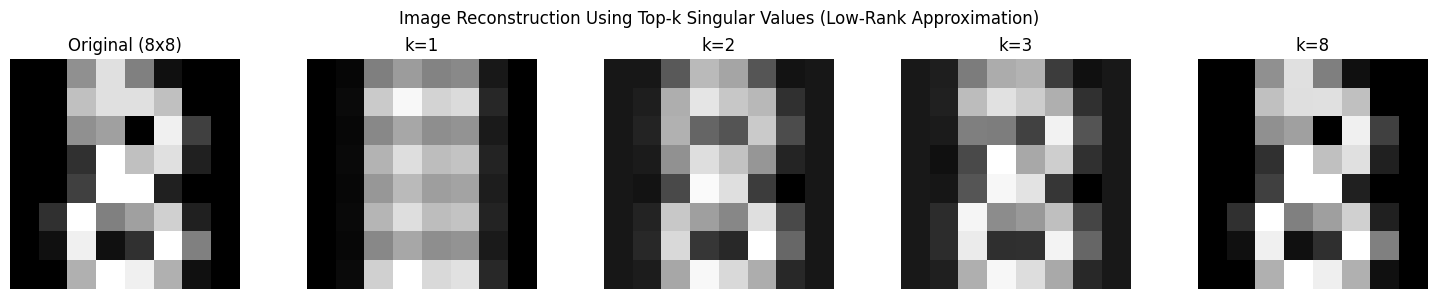


Cumulative energy captured by top-k singular values:
  k=1: 82.88%
  k=2: 95.50%
  k=3: 98.32%
  k=8: 100.00%

Notice: with just k=3 (out of 8 possible), we already capture most
of the image's structure. This is EXACTLY the same idea as PCA's
explained variance ratio - just applied directly to an image matrix
instead of a dataset's covariance matrix.


In [6]:
def reconstruct_image(U, S, Vt, k):
    """
    Reconstruct an image using only the TOP-k singular values.
    This is the LOW-RANK APPROXIMATION: A_k = U[:,:k] @ diag(S[:k]) @ Vt[:k,:]
    """
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
 
 
# Reconstruct using different numbers of singular values
k_values = [1, 2, 3, 8]
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(15, 3))
 
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original (8x8)")
axes[0].axis("off")
 
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(U, S, Vt, k)
    axes[i + 1].imshow(reconstructed, cmap="gray")
    axes[i + 1].set_title(f"k={k}")
    axes[i + 1].axis("off")
 
plt.suptitle("Image Reconstruction Using Top-k Singular Values (Low-Rank Approximation)")
plt.tight_layout()
plt.show()
 
# How much "energy" (variance) does each k capture?
energy = (S ** 2) / np.sum(S ** 2)
cumulative_energy = np.cumsum(energy)
print("\nCumulative energy captured by top-k singular values:")
for k in k_values:
    print(f"  k={k}: {cumulative_energy[k-1]*100:.2f}%")
 
print("\nNotice: with just k=3 (out of 8 possible), we already capture most")
print("of the image's structure. This is EXACTLY the same idea as PCA's")
print("explained variance ratio - just applied directly to an image matrix")
print("instead of a dataset's covariance matrix.")

In [8]:
import pandas as pd

ratings = np.array([
    [5, 4, 0, 1, 0, 1],
    [4, 5, 0, 1, 0, 0],
    [1, 1, 0, 5, 5, 4],
    [1, 0, 1, 4, 4, 5],
    [0, 1, 5, 4, 0, 4],
    [2, 1, 4, 5, 0, 5],
], dtype=float)

In [9]:
print("Original ratings matrix (0 = not yet rated):")
print(pd.DataFrame(ratings, columns=[f"Movie{i}" for i in range(6)],
                    index=[f"User{i}" for i in range(6)]))

Original ratings matrix (0 = not yet rated):
       Movie0  Movie1  Movie2  Movie3  Movie4  Movie5
User0     5.0     4.0     0.0     1.0     0.0     1.0
User1     4.0     5.0     0.0     1.0     0.0     0.0
User2     1.0     1.0     0.0     5.0     5.0     4.0
User3     1.0     0.0     1.0     4.0     4.0     5.0
User4     0.0     1.0     5.0     4.0     0.0     4.0
User5     2.0     1.0     4.0     5.0     0.0     5.0


In [10]:
user_means = np.true_divide(ratings.sum(axis=1), (ratings != 0).sum(axis=1))
ratings_centered = ratings - user_means.reshape(-1, 1)
ratings_centered[ratings == 0] = 0  # keep missing entries as 0 for SVD input
 
print("\nUser means (avg of their NON-ZERO ratings):", user_means.round(2))


User means (avg of their NON-ZERO ratings): [2.75 3.33 3.2  3.   3.5  3.4 ]


In [11]:
U, S, Vt = np.linalg.svd(ratings_centered, full_matrices=False)


In [12]:
k = 2  # assume 2 hidden "taste dimensions" explain most preferences
predicted_centered = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
 
# Add back the user means to get predicted ratings on the original scale
predicted_ratings = predicted_centered + user_means.reshape(-1, 1)

In [13]:
print(f"\nPredicted ratings matrix (using top {k} latent factors):")
print(pd.DataFrame(predicted_ratings.round(2), columns=[f"Movie{i}" for i in range(6)],
                    index=[f"User{i}" for i in range(6)]))


Predicted ratings matrix (using top 2 latent factors):
       Movie0  Movie1  Movie2  Movie3  Movie4  Movie5
User0    4.68    4.31    3.11    1.03    2.05    1.31
User1    4.31    5.12    2.83    2.06    3.06    2.62
User2    1.19    1.11    3.14    5.18    3.89    4.69
User3    0.74    3.20    1.18    4.18    3.99    4.71
User4    3.39    1.21    4.98    4.50    3.36    3.55
User5    1.94    1.01    3.95    5.19    3.84    4.47


In [14]:

print("\nFor entries that were originally 0 (unrated), the predicted value")
print("is SVD's GUESS at what that user would rate that movie - based on")
print("patterns learned from users with SIMILAR rating behavior. This is")
print("the foundation of collaborative filtering recommendation systems.")


For entries that were originally 0 (unrated), the predicted value
is SVD's GUESS at what that user would rate that movie - based on
patterns learned from users with SIMILAR rating behavior. This is
the foundation of collaborative filtering recommendation systems.
